# 퇴직연금 XAI 포트폴리오 최적화 — 팀 브리핑

**작성일**: 2026-05-18  
**대상**: 팀 전원

---

## 오늘 브리핑 내용

| # | 섹션 | 핵심 메시지 |
|---|------|------------|
| B-1 | 프로젝트 목표 & 모델 구조 | 왜 이 모델인가 |
| B-2 | 방치 vs 최적화 | 얼마나 나아졌나 |
| B-3 | 백테스트 성과 | 모멘텀 필터 효과 |
| B-4 | 현재 시점 포트폴리오 | 지금 추천하면? |
| B-5 | 리스크 스코어 UI 데이터 | 슬라이더 연동 준비 |
| B-6 | 데이터 파이프라인 | 학술제 당일 업데이트 방법 |

> ※ 투자 참고 정보입니다. 미래 수익을 보장하지 않으며, 투자 결정은 투자자 본인이 합니다.

In [1]:
import warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from pathlib import Path

warnings.filterwarnings('ignore')
ROOT   = Path('..').resolve()
S5_DIR = ROOT / 'results' / 'step5'
S5B_DIR= ROOT / 'results' / 'step5b'
CUR_DIR= ROOT / 'results' / 'current'

plt.rcParams['font.family']        = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi']         = 110

DISCLAIMER = '※ 투자 참고 정보입니다. 미래 수익을 보장하지 않으며, 투자 결정은 투자자 본인이 합니다.'
SLOTS = [
    '국내주식_코스피', '국내주식_코스닥',
    '미국주식_SP500',  '미국주식_나스닥',
    '신흥국_인도',     '신흥국_중국',
    '국내채권_국고채단중기', '국내채권_국고채장기',
    '국내채권_회사채', '국내채권_종합',
    '해외채권_미국국채', '원자재_금', '무위험(현금성)',
]
RF_SLOT = '무위험(현금성)'

perf5  = pd.read_parquet(S5_DIR  / 'portfolio_performance_constrained.parquet')
perf5b = pd.read_parquet(S5B_DIR / 'portfolio_performance_constrained.parquet')
w5b    = pd.read_parquet(S5B_DIR / 'portfolio_weights_constrained.parquet')
bind5  = pd.read_parquet(S5_DIR  / 'binding_history.parquet')
bind5b = pd.read_parquet(S5B_DIR / 'binding_history.parquet')
idx_rets = pd.read_parquet(ROOT / 'data' / 'index_returns.parquet').reindex(columns=SLOTS)
cal_df   = pd.read_csv(CUR_DIR / 'current_cal_allocations.csv')
meta     = json.load(open(CUR_DIR / 'current_meta.json', encoding='utf-8'))
w5b.columns = SLOTS

mar_monthly = pd.read_parquet(ROOT / 'data' / 'mar_series.parquet')['mar_annual']
mar_daily   = mar_monthly.resample('D').ffill().reindex(idx_rets.index).ffill().bfill() / 100
yeb = pd.read_csv(ROOT / 'data' / 'year_end_best.csv')
aum_by_year = {}
for yr, grp in yeb.groupby('year'):
    aum_by_year[int(yr)] = dict(zip(grp['slot'], grp['aum_억'].astype(float)))

cum5  = (1 + perf5['cum_ret_pct'] /100).cumprod()
cum5b = (1 + perf5b['cum_ret_pct']/100).cumprod()
mar_q = perf5['mar_annual_pct'] / 4
mar_q_arr = mar_q.values

print('데이터 로드 완료')
print(f'  백테스트: {len(perf5)}분기  ({perf5.index.min().date()} ~ {perf5.index.max().date()})')
print(f'  현재 배분 기준일: {meta["as_of_date"]}')

데이터 로드 완료
  백테스트: 38분기  (2016-01-29 ~ 2025-01-16)
  현재 배분 기준일: 2025-04-30


---
## B-1. 프로젝트 목표 & 모델 구조

```
문제: 퇴직연금 가입자 대부분이 원리금보장형(예금 수준)에 방치
      → 고령화 시대에 은퇴 후 자산 부족 위험

목표: 개인 리스크 성향에 맞는 최적 포트폴리오 자동 추천 + XAI 설명
```

### 모델 파이프라인

```
[데이터]  13개 ETF 슬롯 (국내·미국·신흥국 주식 / 국내·해외 채권 / 금 / 현금)
    ↓
[추정]    5년 롤링 윈도우 → Black-Litterman 내재수익률(Π) + 하방공분산(Σ_down)
    ↓
[최적화]  Sortino-max (MAR 초과 수익 / 하방위험 최대화)
          제약: US≤50%, KR≤50%, EM≤15%
    ↓  모멘텀 필터 (B+C)
    ↓  음(-)모멘텀 슬롯 제외 + AUM×모멘텀 w_mkt 재조정
    ↓
[배분]    CAL (Capital Allocation Line)
          리스크 스코어 → w_risky → 최종 배분
    ↓
[XAI]    사용자 설명 (step8a) + 분석용 리포트 (step8b)
```

---
## B-2. 방치된 포트폴리오 vs 최적화 전략

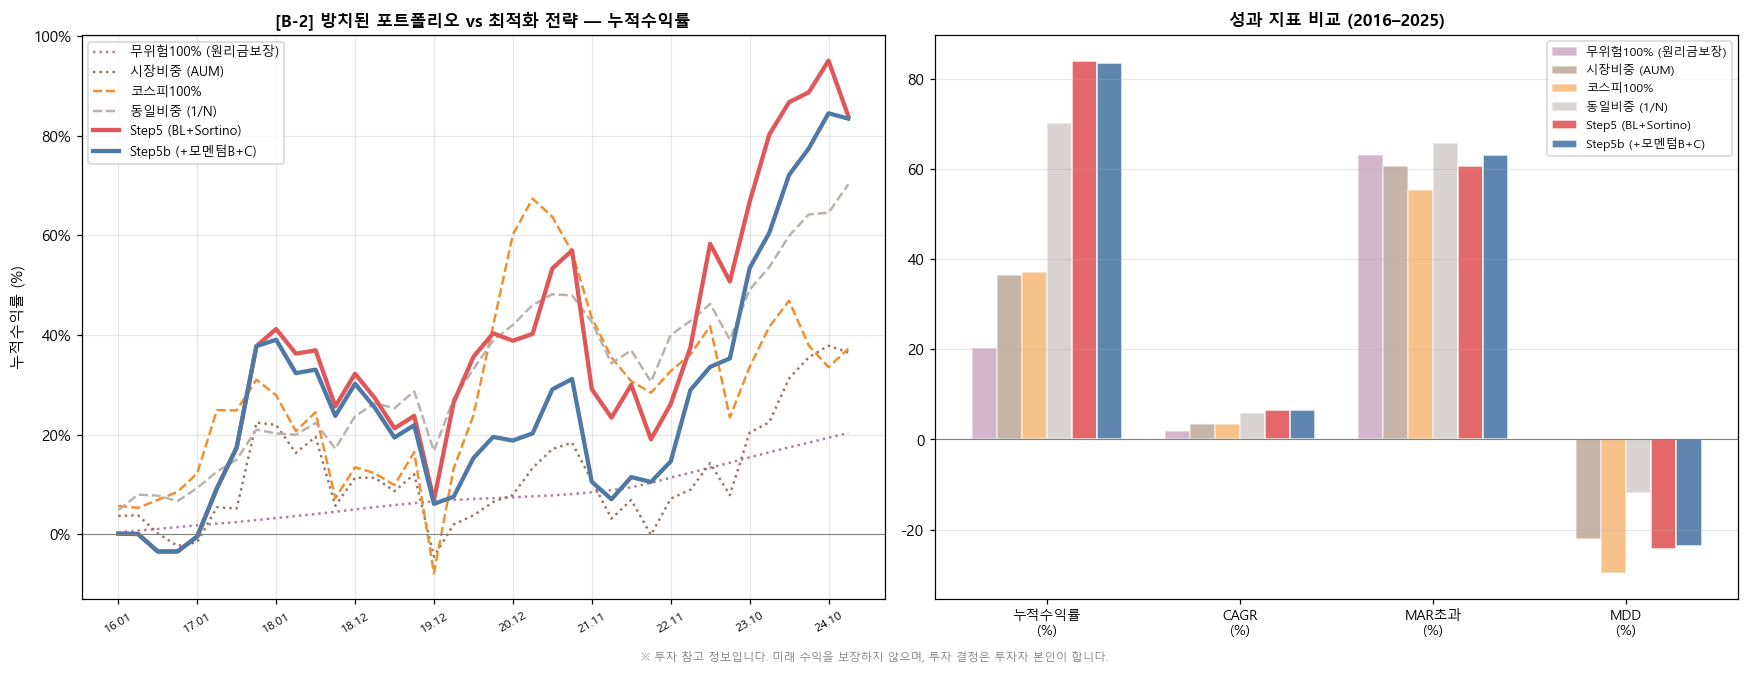

전략                         누적    CAGR    MAR초과      MDD
--------------------------------------------------------
무위험100% (원리금보장)         20.3%   1.97%    63.2%    0.00%
시장비중 (AUM)              36.5%   3.33%    60.5%  -22.00%
코스피100%                 37.2%   3.39%    55.3%  -29.69%
동일비중 (1/N)              70.3%   5.76%    65.8%  -11.86%
Step5 (BL+Sortino)      84.0%   6.63%    60.5%  -24.35%
Step5b (+모멘텀B+C)        83.4%   6.60%    63.2%  -23.70% ◀ 최적화


In [2]:
rebal_dates = perf5.index.tolist()
bl_rows = {'date':[], 'eq_ret':[], 'rf_ret':[], 'mktcap_ret':[], 'kospi_ret':[]}
for i, d in enumerate(rebal_dates):
    end   = rebal_dates[i+1] if i+1<len(rebal_dates) else idx_rets.index[-1]
    oos   = idx_rets.loc[d:end]
    valid = [s for s in SLOTS if oos[s].dropna().__len__() > 5]
    w_eq  = 1.0/len(valid)
    eq_q  = sum(float((1+oos[s].dropna()).prod()-1)*w_eq for s in valid)*100
    rf_q  = float((1+oos[RF_SLOT].dropna()).prod()-1)*100
    ref_yr = d.year-1
    if ref_yr not in aum_by_year: ref_yr = max(k for k in aum_by_year if k<=d.year)
    aum_d = aum_by_year[ref_yr]; valid_aum=[s for s in valid if s in aum_d]
    tot   = sum(aum_d[s] for s in valid_aum)
    mkt_q = sum(float((1+oos[s].dropna()).prod()-1)*aum_d[s]/tot for s in valid_aum)*100
    kos_q = float((1+oos['국내주식_코스피'].dropna()).prod()-1)*100
    bl_rows['date'].append(d); bl_rows['eq_ret'].append(eq_q)
    bl_rows['rf_ret'].append(rf_q); bl_rows['mktcap_ret'].append(mkt_q)
    bl_rows['kospi_ret'].append(kos_q)
base_df = pd.DataFrame(bl_rows).set_index('date')

def cum_s(arr): return (1+np.array(arr)/100).cumprod()
def stats(arr):
    c=cum_s(arr); mdd=((c-np.maximum.accumulate(c))/np.maximum.accumulate(c)).min()*100
    return {'누적':(c[-1]-1)*100,'CAGR':(c[-1]**(4/len(c))-1)*100,
            'MAR초과':(np.array(arr)>=mar_q_arr).mean()*100,'MDD':mdd}

STRATS = {
    '무위험100%\n(원리금보장)': base_df['rf_ret'].values,
    '시장비중\n(AUM)':          base_df['mktcap_ret'].values,
    '코스피100%':               base_df['kospi_ret'].values,
    '동일비중\n(1/N)':          base_df['eq_ret'].values,
    'Step5\n(BL+Sortino)':     perf5['cum_ret_pct'].values,
    'Step5b\n(+모멘텀B+C)':    perf5b['cum_ret_pct'].values,
}
COLORS = ['#b07aa1','#9c755f','#f28e2b','#bab0ac','#e15759','#4e79a7']
STYLES = [':',':','--','--','-','-']
x_q  = np.arange(len(rebal_dates))
xlbl = [d.strftime('%y.%m') for d in rebal_dates]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 누적수익률 시계열
ax = axes[0]
for (name,ret), clr, ls in zip(STRATS.items(), COLORS, STYLES):
    lw = 2.8 if 'Step5' in name else 1.6
    ax.plot(x_q, (cum_s(ret)-1)*100, ls=ls, color=clr, lw=lw, label=name.replace('\n',' '))
ax.axhline(0, color='gray', lw=0.7)
ax.set_xticks(x_q[::4]); ax.set_xticklabels(xlbl[::4], rotation=30, fontsize=8)
ax.set_ylabel('누적수익률 (%)', fontsize=10)
ax.set_title('[B-2] 방치된 포트폴리오 vs 최적화 전략 — 누적수익률', fontsize=11, fontweight='bold')
ax.legend(fontsize=8.5, loc='upper left'); ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}%'))

# 성과 지표 비교 바
ax2 = axes[1]
metric_lbls = ['누적수익률\n(%)', 'CAGR\n(%)', 'MAR초과\n(%)', 'MDD\n(%)']
n_s = len(STRATS); bw = 0.13
offs = np.linspace(-(n_s-1)/2,(n_s-1)/2,n_s)*bw
xm = np.arange(4)
for i, ((name,ret), clr) in enumerate(zip(STRATS.items(), COLORS)):
    s = stats(ret)
    vals = [s['누적'], s['CAGR'], s['MAR초과'], s['MDD']]
    alpha = 0.90 if 'Step5' in name else 0.55
    ax2.bar(xm+offs[i], vals, bw, color=clr, alpha=alpha, edgecolor='white',
            label=name.replace('\n',' '))
ax2.axhline(0, color='gray', lw=0.7)
ax2.set_xticks(xm); ax2.set_xticklabels(metric_lbls, fontsize=9)
ax2.set_title('성과 지표 비교 (2016–2025)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8, loc='upper right'); ax2.grid(axis='y', alpha=0.3)

fig.text(0.5,-0.01,DISCLAIMER,ha='center',fontsize=7.5,color='gray',style='italic')
plt.tight_layout(); plt.show()

print(f'{'전략':<20} {'누적':>8} {'CAGR':>7} {'MAR초과':>8} {'MDD':>8}')
print('-'*56)
for (name,ret), clr in zip(STRATS.items(), COLORS):
    s=stats(ret); mark=' ◀ 최적화' if 'Step5b' in name else ''
    print(f"{name.replace(chr(10),' '):<20} {s['누적']:>7.1f}% {s['CAGR']:>6.2f}% {s['MAR초과']:>7.1f}% {s['MDD']:>7.2f}%{mark}")

---
## B-3. 백테스트 성과 — Step5 vs Step5b (모멘텀 B+C 필터)

**모멘텀 B+C**:
- **[B]** 직전 12개월 수익률 < 0인 슬롯을 해당 분기에서 제외
- **[C]** `w_mkt = AUM × max(1 + 모멘텀수익률, 0.02)` — 강한 자산에 더 높은 시장비중 부여

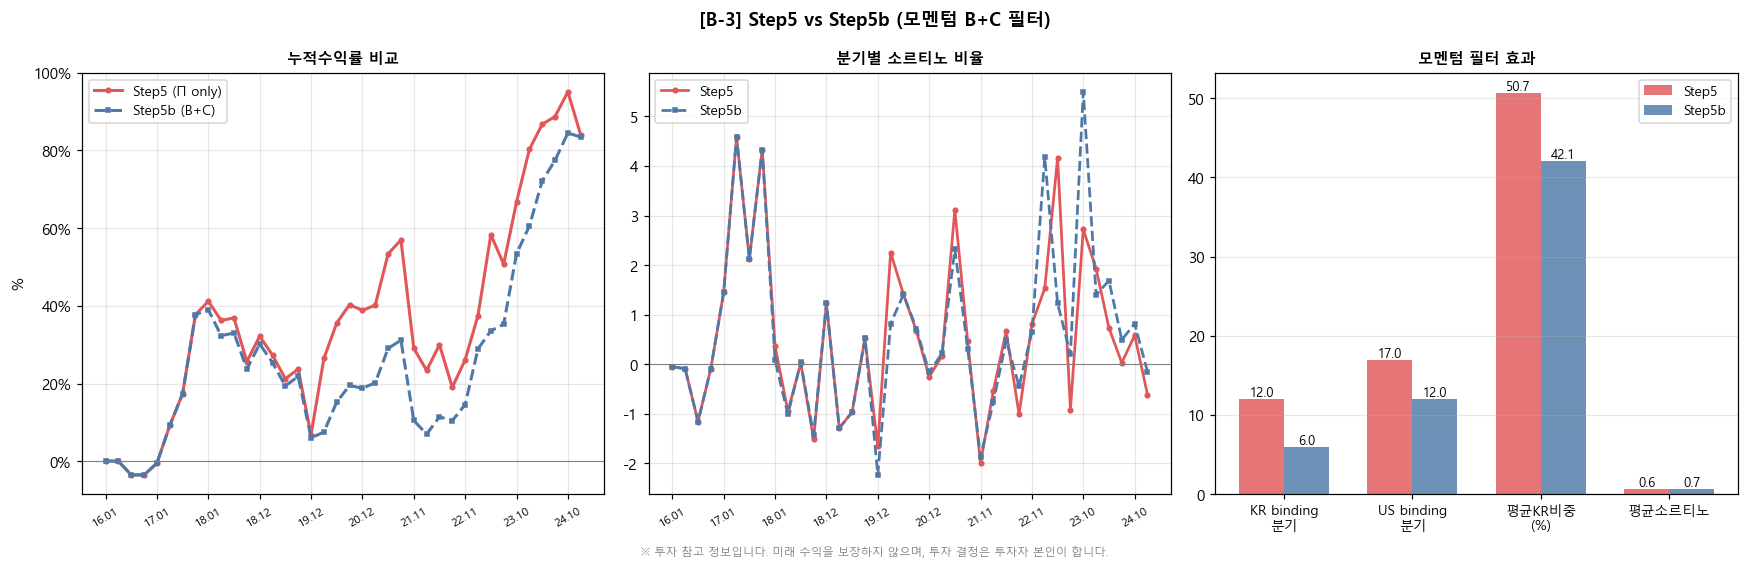

핵심 개선 사항:
  소르티노  0.599 → 0.659  (+6.0%)
  KR binding  12/38 → 6/38  (절반 감소)
  KR 평균비중  50.7% → 42.1%  (-8.6%p 분산 개선)
  MDD          -24.35% → -23.70%  (0.65%p 개선)


In [3]:
x_q2  = np.arange(len(perf5))
xlbl2 = [d.strftime('%y.%m') for d in perf5.index]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 누적수익률
ax = axes[0]
ax.plot(x_q2, (cum5-1)*100,  '-o', color='#e15759', ms=3, lw=2,   label='Step5 (Π only)')
ax.plot(x_q2, (cum5b-1)*100, '--s',color='#4e79a7', ms=3, lw=2,   label='Step5b (B+C)')
ax.axhline(0,color='gray',lw=0.7)
ax.set_title('누적수익률 비교', fontsize=10, fontweight='bold')
ax.set_ylabel('%'); ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_xticks(x_q2[::4]); ax.set_xticklabels(xlbl2[::4], rotation=30, fontsize=7.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_:f'{v:.0f}%'))

# 분기 소르티노
ax2 = axes[1]
ax2.plot(x_q2, perf5['sortino'].values,  '-o', color='#e15759', ms=3, lw=1.8, label='Step5')
ax2.plot(x_q2, perf5b['sortino'].values, '--s',color='#4e79a7', ms=3, lw=1.8, label='Step5b')
ax2.axhline(0,color='gray',lw=0.7)
ax2.set_title('분기별 소르티노 비율', fontsize=10, fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
ax2.set_xticks(x_q2[::4]); ax2.set_xticklabels(xlbl2[::4], rotation=30, fontsize=7.5)

# KR binding 감소
ax3 = axes[2]
metrics_b  = ['KR binding\n분기', 'US binding\n분기', '평균KR비중\n(%)', '평균소르티노']
v5  = [bind5['kr_binding'].sum(), bind5['us_binding'].sum(),
       50.7, perf5['sortino'].mean()]
v5b = [bind5b['kr_binding'].sum(), bind5b['us_binding'].sum(),
       42.1, perf5b['sortino'].mean()]
xb = np.arange(len(metrics_b)); wb=0.35
b1=ax3.bar(xb-wb/2, v5,  wb, color='#e15759', alpha=0.82, label='Step5')
b2=ax3.bar(xb+wb/2, v5b, wb, color='#4e79a7', alpha=0.82, label='Step5b')
for bar in list(b1)+list(b2):
    v=bar.get_height()
    ax3.text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}', ha='center', fontsize=8.5)
ax3.axhline(0,color='gray',lw=0.7)
ax3.set_xticks(xb); ax3.set_xticklabels(metrics_b, fontsize=9)
ax3.set_title('모멘텀 필터 효과', fontsize=10, fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(axis='y',alpha=0.3)

fig.suptitle('[B-3] Step5 vs Step5b (모멘텀 B+C 필터)', fontsize=12, fontweight='bold')
fig.text(0.5,-0.01,DISCLAIMER,ha='center',fontsize=7.5,color='gray',style='italic')
plt.tight_layout(); plt.show()

print('핵심 개선 사항:')
print(f'  소르티노  {perf5["sortino"].mean():.3f} → {perf5b["sortino"].mean():.3f}  (+{(perf5b["sortino"].mean()-perf5["sortino"].mean())*100:.1f}%)')
print(f'  KR binding  {bind5["kr_binding"].sum()}/38 → {bind5b["kr_binding"].sum()}/38  (절반 감소)')
print(f'  KR 평균비중  50.7% → 42.1%  (-8.6%p 분산 개선)')
print(f'  MDD          -24.35% → -23.70%  (0.65%p 개선)')

---
## B-4. 현재 시점 포트폴리오

**기준일**: 2025-04-30 (데이터 최종 업데이트 기준)  
**추정 윈도우**: 2020-06-29 ~ 2025-04-30 (5년, 1260거래일)

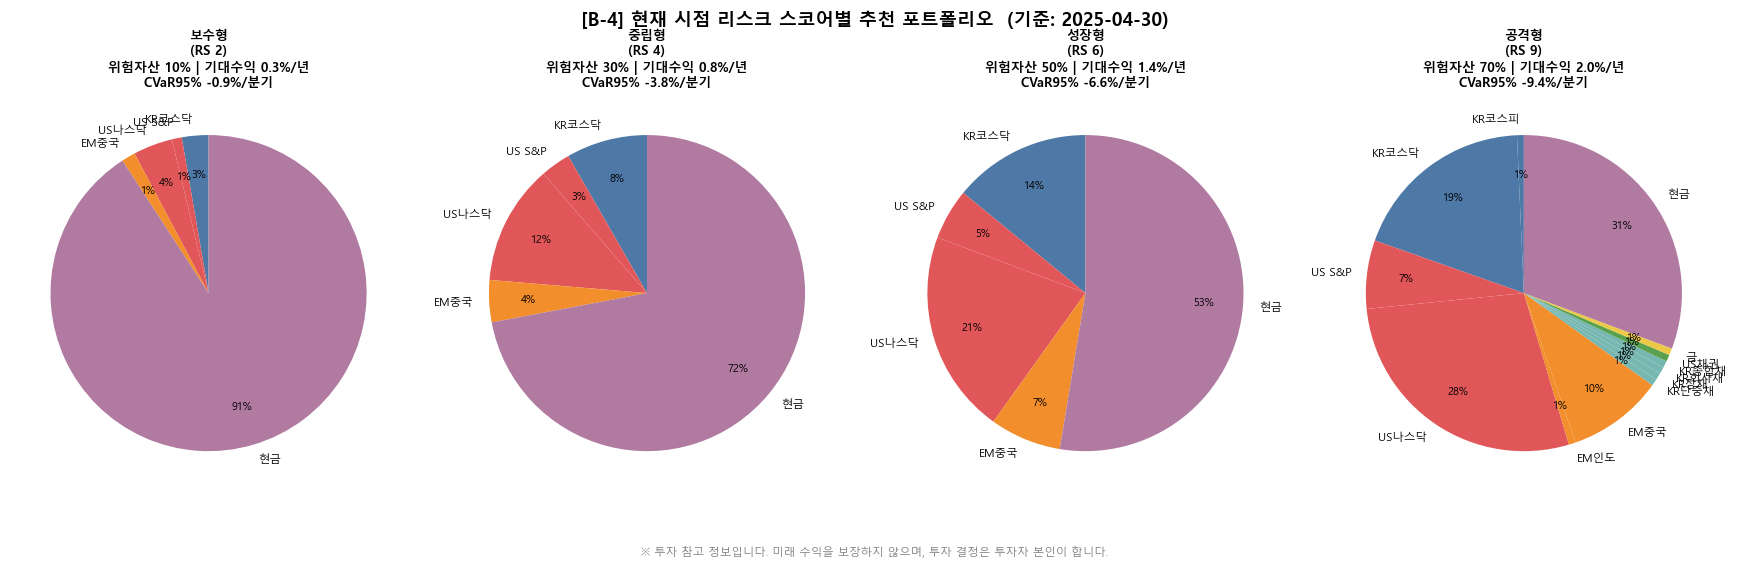

In [4]:
w_sortino = pd.read_csv(CUR_DIR / 'current_weights_sortino.csv', index_col=0)

# 리스크 유형별 컬러
GROUP_COLORS = {
    '국내주식_코스피':'#4e79a7','국내주식_코스닥':'#4e79a7',
    '미국주식_SP500':'#e15759', '미국주식_나스닥':'#e15759',
    '신흥국_인도':'#f28e2b',    '신흥국_중국':'#f28e2b',
    '국내채권_국고채단중기':'#76b7b2','국내채권_국고채장기':'#76b7b2',
    '국내채권_회사채':'#76b7b2', '국내채권_종합':'#76b7b2',
    '해외채권_미국국채':'#59a14f',
    '원자재_금':'#edc948',
    '무위험(현금성)':'#b07aa1',
}
SHORT = {
    '국내주식_코스피':'KR코스피','국내주식_코스닥':'KR코스닥',
    '미국주식_SP500':'US S&P','미국주식_나스닥':'US나스닥',
    '신흥국_인도':'EM인도','신흥국_중국':'EM중국',
    '국내채권_국고채단중기':'KR단중채','국내채권_국고채장기':'KR장채',
    '국내채권_회사채':'KR회사채','국내채권_종합':'KR종합채',
    '해외채권_미국국채':'US채권','원자재_금':'금','무위험(현금성)':'현금',
}

# 대표 리스크 스코어 4개
DEMO_RS = [2.0, 4.0, 6.0, 9.0]
RS_LABELS = {2.0:'보수형\n(RS 2)', 4.0:'중립형\n(RS 4)',
             6.0:'성장형\n(RS 6)', 9.0:'공격형\n(RS 9)'}

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, rs in zip(axes, DEMO_RS):
    row = cal_df[cal_df['risk_score']==rs].iloc[0]
    active = {s: row[s] for s in SLOTS if row[s] > 0.005}
    labels = [SHORT[s] for s in active]
    sizes  = list(active.values())
    colors = [GROUP_COLORS[s] for s in active]
    wedges, texts, autotexts = ax.pie(
        sizes, labels=labels, autopct='%1.0f%%',
        colors=colors, startangle=90,
        pctdistance=0.75, textprops={'fontsize':7.5}
    )
    for at in autotexts: at.set_fontsize(7)
    w_r = row['w_risky']
    exp  = row['exp_ret_ann_pct']
    cvar = row['cvar_95_q_pct']
    ax.set_title(f"{RS_LABELS[rs]}\n위험자산 {w_r*100:.0f}% | 기대수익 {exp:.1f}%/년\nCVaR95% {cvar:.1f}%/분기",
                 fontsize=8.5, fontweight='bold')

fig.suptitle(f'[B-4] 현재 시점 리스크 스코어별 추천 포트폴리오  (기준: {meta["as_of_date"]})',
             fontsize=12, fontweight='bold')
fig.text(0.5,-0.01,DISCLAIMER,ha='center',fontsize=7.5,color='gray',style='italic')
plt.tight_layout(); plt.show()

---
## B-5. 리스크 스코어 슬라이더 — UI 연동 데이터

슬라이더가 RS 1→10으로 이동할 때 기대수익·CVaR가 어떻게 변하는지 시각화.

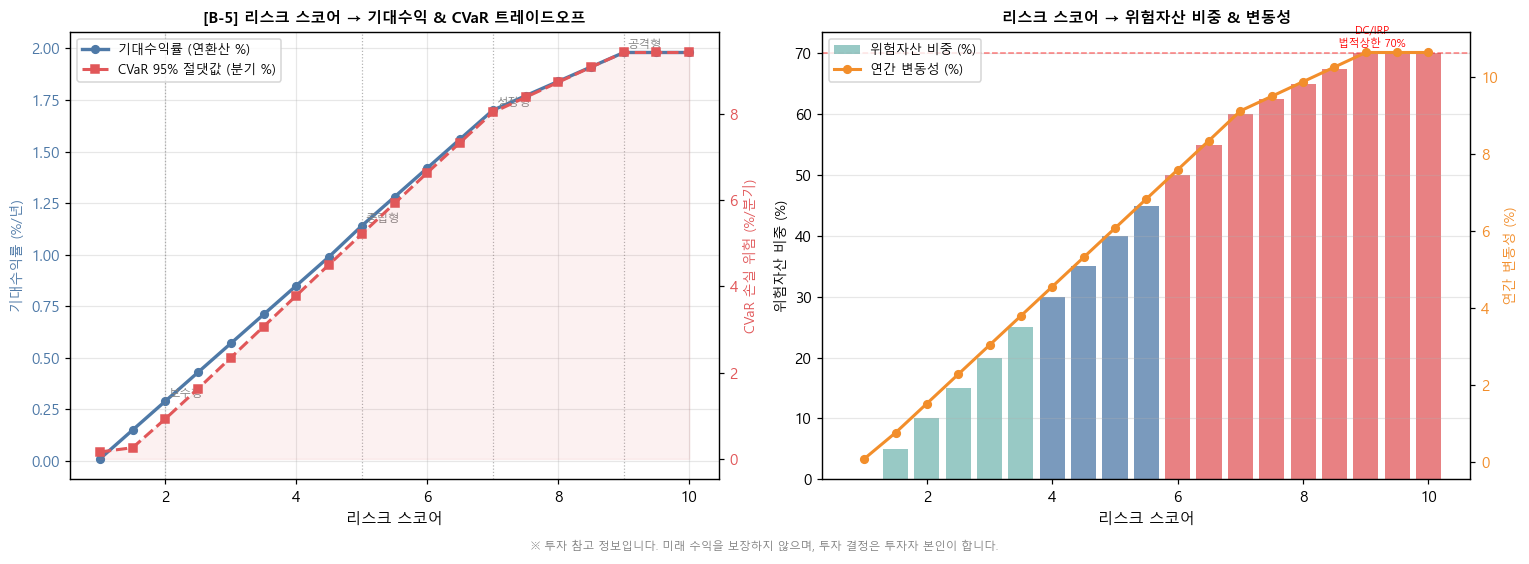

UI 팀 전달 파일: results/current/current_cal_allocations.csv
  → RS 1.0~10.0  19행 × (비중 13개 + 위험지표 4개) 컬럼

컬럼 구조:
  risk_score
  w_risky
  exp_ret_ann_pct
  vol_ann_pct
  down_risk_q_pct
  cvar_95_q_pct
  + 슬롯 비중 13개


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rs_vals  = cal_df['risk_score'].values
exp_ret  = cal_df['exp_ret_ann_pct'].values
vol_ann  = cal_df['vol_ann_pct'].values
cvar_q   = cal_df['cvar_95_q_pct'].values
down_q   = cal_df['down_risk_q_pct'].values
w_risky  = cal_df['w_risky'].values * 100

# ── 기대수익률 & 위험 동시 표시 ──
ax = axes[0]
ax.plot(rs_vals, exp_ret, '-o', color='#4e79a7', lw=2.2, ms=5, label='기대수익률 (연환산 %)')
ax2t = ax.twinx()
ax2t.plot(rs_vals, np.abs(cvar_q), '--s', color='#e15759', lw=2, ms=5,
          label='CVaR 95% 절댓값 (분기 %)')
ax2t.fill_between(rs_vals, np.abs(cvar_q), alpha=0.08, color='#e15759')
ax.set_xlabel('리스크 스코어', fontsize=10)
ax.set_ylabel('기대수익률 (%/년)', color='#4e79a7', fontsize=9)
ax2t.set_ylabel('CVaR 손실 위험 (%/분기)', color='#e15759', fontsize=9)
ax.set_title('[B-5] 리스크 스코어 → 기대수익 & CVaR 트레이드오프', fontsize=10, fontweight='bold')
ax.tick_params(axis='y', labelcolor='#4e79a7')
ax2t.tick_params(axis='y', labelcolor='#e15759')
lines1, lbls1 = ax.get_legend_handles_labels()
lines2, lbls2 = ax2t.get_legend_handles_labels()
ax.legend(lines1+lines2, lbls1+lbls2, fontsize=8.5, loc='upper left')
ax.grid(alpha=0.3)
# 대표 위험군 레이블
for rs_v, lbl in [(2,'보수형'),(5,'중립형'),(7,'성장형'),(9,'공격형')]:
    idx = cal_df[cal_df['risk_score']==float(rs_v)].index[0]
    ax.axvline(rs_v, color='gray', lw=0.8, ls=':', alpha=0.6)
    ax.text(rs_v+0.05, exp_ret[cal_df.index.get_loc(idx)]+0.02, lbl, fontsize=7.5, color='gray')

# ── 위험자산 비중 & 변동성 ──
ax3 = axes[1]
ax3.bar(rs_vals, w_risky, width=0.4,
        color=['#e15759' if w>=50 else '#4e79a7' if w>=30 else '#76b7b2' for w in w_risky],
        alpha=0.75, label='위험자산 비중 (%)')
ax3t = ax3.twinx()
ax3t.plot(rs_vals, vol_ann, '-o', color='#f28e2b', lw=2, ms=5, label='연간 변동성 (%)')
ax3.set_xlabel('리스크 스코어', fontsize=10)
ax3.set_ylabel('위험자산 비중 (%)', fontsize=9)
ax3t.set_ylabel('연간 변동성 (%)', color='#f28e2b', fontsize=9)
ax3.set_title('리스크 스코어 → 위험자산 비중 & 변동성', fontsize=10, fontweight='bold')
ax3t.tick_params(axis='y', labelcolor='#f28e2b')
lines3, lbls3 = ax3.get_legend_handles_labels()
lines4, lbls4 = ax3t.get_legend_handles_labels()
ax3.legend(lines3+lines4, lbls3+lbls4, fontsize=8.5, loc='upper left')
ax3.grid(alpha=0.3, axis='y')
ax3.axhline(70, color='red', ls='--', lw=1, alpha=0.5)
ax3.text(9.1, 71, 'DC/IRP\n법적상한 70%', fontsize=7, color='red', ha='center')

fig.text(0.5,-0.01,DISCLAIMER,ha='center',fontsize=7.5,color='gray',style='italic')
plt.tight_layout(); plt.show()

print(f'UI 팀 전달 파일: results/current/current_cal_allocations.csv')
print(f'  → RS 1.0~10.0  19행 × (비중 13개 + 위험지표 4개) 컬럼')
print(f'\n컬럼 구조:')
for c in ['risk_score','w_risky','exp_ret_ann_pct','vol_ann_pct','down_risk_q_pct','cvar_95_q_pct']:
    print(f'  {c}')
print(f'  + 슬롯 비중 13개')

---
## B-6. 학술제 당일 데이터 업데이트 방법

```bash
# 1단계: 인덱스 데이터 갱신 (yfinance + ECOS API)
#   기본값: 오늘 날짜까지 자동 수집
python src/step3_collect_data.py

#   또는 날짜 직접 지정
python src/step3_collect_data.py --end 2026-06-15

# 2단계: 현재 시점 최적 배분 재산출
python src/step6b_current_allocation.py

# → results/current/ 갱신 완료
#   current_cal_allocations.csv  ← UI 팀에 전달
#   current_meta.json            ← 기준일 확인용
```

### 전체 파이프라인 흐름

```
step3 (데이터 수집)       → data/index_returns.parquet
                               ↓
step6b (현재 배분 산출)   → results/current/current_cal_allocations.csv
                               ↓
UI 서비스                → 리스크 스코어 입력 → 슬롯 비중 + 기대수익·위험 출력
```

---

## 정리

| 항목 | 상태 |
|------|------|
| 백테스트 (2016–2025) | ✅ 완료 (Step5b B+C 기준) |
| 베이스라인 비교 | ✅ 완료 (8-D 섹션) |
| 현재 시점 배분 | ✅ 완료 (2025-04-30 기준) |
| UI용 위험지표 | ✅ 완료 (CSV 4개 컬럼) |
| 데이터 파이프라인 | ✅ 완료 (`--end` 인수 지원) |
| XAI 노트북 (8a/8b) | ✅ v3 기준 재실행 완료 |
| 학술제 당일 업데이트 | 🔲 step3 → step6b 실행 필요 |
| UI 슬라이더 연동 | 🔲 UI 팀 작업 |

> ※ 투자 참고 정보입니다. 미래 수익을 보장하지 않으며, 투자 결정은 투자자 본인이 합니다.